<a href="https://colab.research.google.com/github/Sneha8126/Python-Assignment/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
df=pd.read_csv('/content/drive/MyDrive/Mall_Customers.csv')

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [28]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [30]:
df.shape

(200, 5)

In [31]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [32]:
df['Genre'].value_counts()

,count
Genre,
Female,112
Male,88


In [33]:
df['Genre'] = df['Genre'].map({
    'Male': 0,
    'Female': 1
})

In [34]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


In [35]:
x = df.iloc[:,1:]
x

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40
...,...,...,...,...
195,1,35,120,79
196,1,45,126,28
197,0,32,126,74
198,0,32,137,18


In [36]:
import scipy.cluster.hierarchy as sch

In [37]:
import matplotlib.pyplot as plt

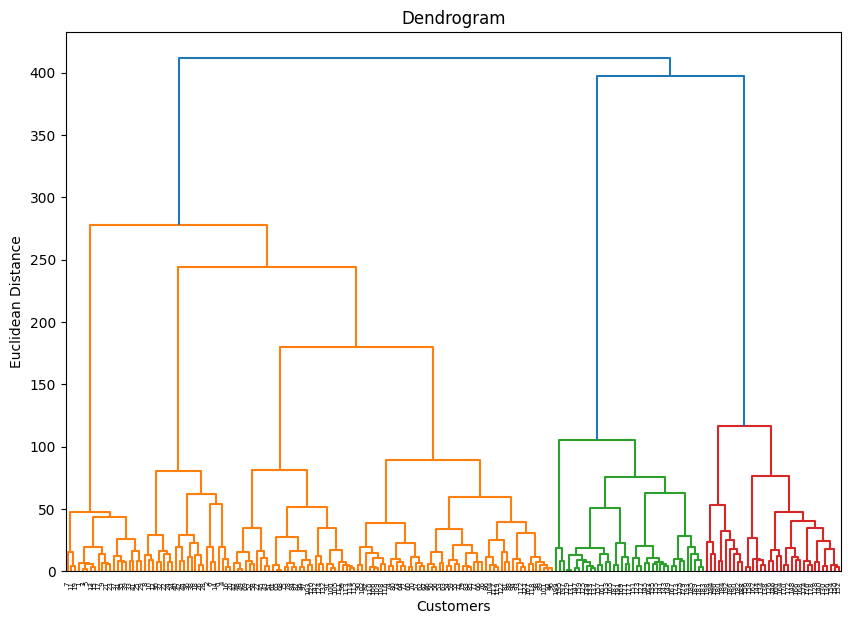

In [38]:
plt.figure(figsize=(10,7))

dendrogram = sch.dendrogram(
    sch.linkage(x, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [39]:
from sklearn.cluster import KMeans

k_range = range(1,11)

inertia_values = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(x)

    inertia_values.append(kmeans.inertia_)

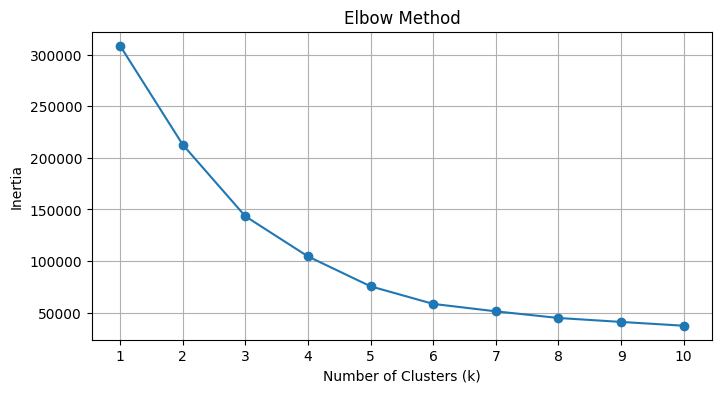

In [40]:
plt.figure(figsize=(8,4))

plt.plot(k_range, inertia_values, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (k)")

plt.ylabel("Inertia")

plt.xticks(k_range)

plt.grid(True)

plt.show()

In [41]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

y_hc = hc.fit_predict(x)

In [42]:
y_hc

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 0, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 0,
       4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2,
       0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2])

In [43]:
df['aglo_y'] = y_hc

In [44]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),aglo_y
0,1,0,19,15,39,4
1,2,0,21,15,81,3
2,3,1,20,16,6,4
3,4,1,23,16,77,3
4,5,1,31,17,40,4


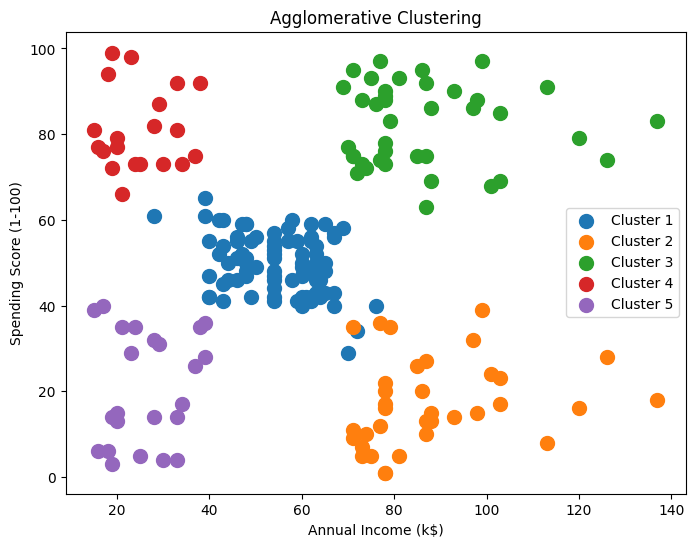

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(
    x.iloc[y_hc==0,2],
    x.iloc[y_hc==0,3],
    s=100,
    label='Cluster 1'
)

plt.scatter(
    x.iloc[y_hc==1,2],
    x.iloc[y_hc==1,3],
    s=100,
    label='Cluster 2'
)

plt.scatter(
    x.iloc[y_hc==2,2],
    x.iloc[y_hc==2,3],
    s=100,
    label='Cluster 3'
)

plt.scatter(
    x.iloc[y_hc==3,2],
    x.iloc[y_hc==3,3],
    s=100,
    label='Cluster 4'
)

plt.scatter(
    x.iloc[y_hc==4,2],
    x.iloc[y_hc==4,3],
    s=100,
    label='Cluster 5'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Agglomerative Clustering")
plt.legend()

plt.show()

In [46]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(x)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [47]:
labels = kmeans.labels_

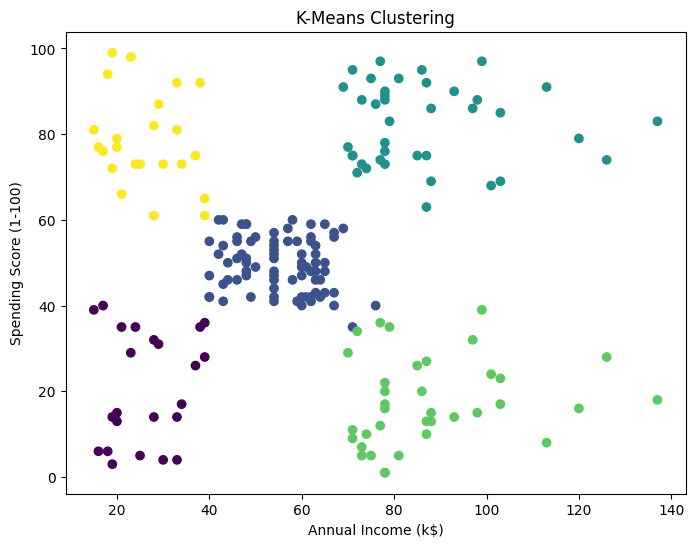

In [48]:
plt.figure(figsize=(8,6))

plt.scatter(
    x.iloc[:,2],
    x.iloc[:,3],
    c=labels
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clustering")

plt.show()

In [49]:
import plotly.express as px

df_plot = x.copy()

df_plot["Cluster"] = labels.astype(str)

fig = px.scatter_3d(
    df_plot,
    x=df_plot.columns[1],   # Age
    y=df_plot.columns[2],   # Annual Income
    z=df_plot.columns[3],   # Spending Score
    color="Cluster"
)

fig.show()

In [50]:
silhouette_scores = []

for k in range(2, 11):      # Silhouette Score starts from k=2
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(x)

    score = silhouette_score(x, labels)

    silhouette_scores.append(score)

    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 2, Silhouette Score = 0.2931
k = 3, Silhouette Score = 0.3838
k = 4, Silhouette Score = 0.4053
k = 5, Silhouette Score = 0.4441
k = 6, Silhouette Score = 0.4521
k = 7, Silhouette Score = 0.4409
k = 8, Silhouette Score = 0.4325
k = 9, Silhouette Score = 0.3979
k = 10, Silhouette Score = 0.3815


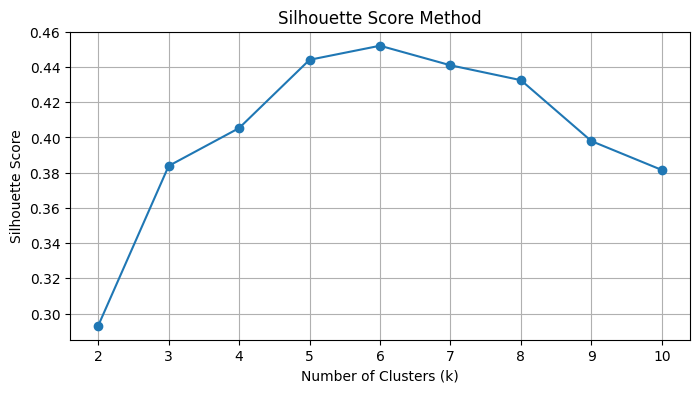

In [51]:
plt.figure(figsize=(8,4))

plt.plot(range(2,11), silhouette_scores, marker='o')

plt.title("Silhouette Score Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.xticks(range(2,11))
plt.grid(True)

plt.show()

In [52]:
X = df[['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [54]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [55]:
X_pca

array([[-4.06382715e-01, -5.20713635e-01],
       [-1.42767287e+00, -3.67310199e-01],
       [ 5.07605706e-02, -1.89406774e+00],
       [-1.69451310e+00, -1.63190805e+00],
       [-3.13108383e-01, -1.81048272e+00],
       [-1.71744627e+00, -1.59926418e+00],
       [ 7.90821124e-01, -1.94727112e+00],
       [-2.14832159e+00, -1.50537369e+00],
       [ 2.77428623e+00, -8.82987672e-01],
       [-1.21629477e+00, -1.61640464e+00],
       [ 2.62905084e+00, -8.61237043e-01],
       [-1.68947038e+00, -1.54542784e+00],
       [ 1.68582253e+00, -2.02394479e+00],
       [-1.64607339e+00, -1.52251259e+00],
       [ 1.17443628e+00, -6.12790961e-01],
       [-1.32613070e+00, -2.36719149e-01],
       [ 1.67728253e-02, -1.74344572e+00],
       [-1.07842454e+00, -2.44715641e-01],
       [ 1.48758780e+00, -5.72676028e-01],
       [-1.66373169e+00, -1.43259774e+00],
       [ 4.88090311e-01, -3.92921145e-01],
       [-1.01895051e+00, -1.66247511e-01],
       [ 1.35891492e+00, -1.82866936e+00],
       [-7.

In [56]:
print(X.shape)
print(X_pca.shape)

(200, 4)
(200, 2)


In [57]:
print(pca.explained_variance_ratio_)

[0.33690046 0.26230645]


In [58]:
print(sum(pca.explained_variance_ratio_))

0.5992069019819846


In [59]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_pca)

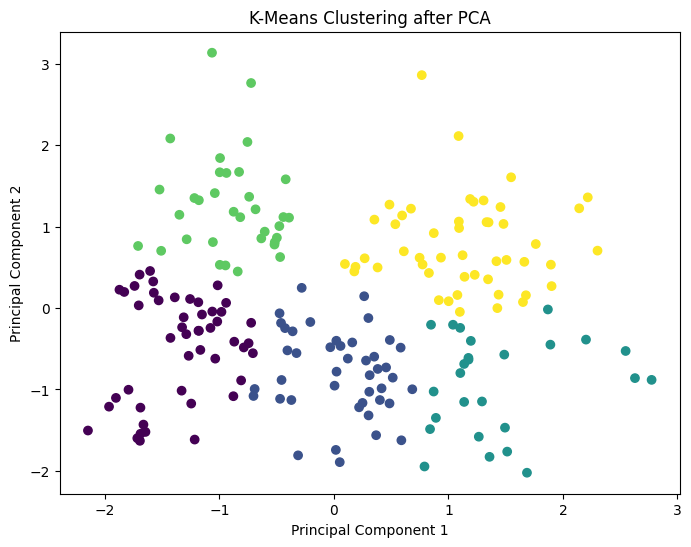

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering after PCA")

plt.show()